## Diabetes Readmission Prediction — Machine Learning

### Project Objective

The objective of this machine learning phase is to develop predictive models that identify patients at higher risk of hospital readmission.

The models will use patient demographics, clinical characteristics, healthcare utilisation history, medication information, admission details, and discharge information identified during the exploratory analysis.

The goal is to support early identification of high-risk patients and provide insights that may help healthcare providers improve discharge planning and reduce avoidable readmissions.

In [1]:
# Import libraries required for data loading, preprocessing, modelling, and evaluation

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

## Load Cleaned Dataset

The cleaned dataset created during the data preparation phase will be loaded for machine learning.

This dataset contains the processed patient encounter records after handling data quality issues and preparing the variables for analysis.

In [2]:
# Load the cleaned diabetes dataset from the Kaggle input dataset
# This dataset was created during the EDA and cleaning phase

import pandas as pd

file_path = '/kaggle/input/datasets/neelamsingh1987/diabetes-cleaned/diabetes_cleaned.csv'

df = pd.read_csv(file_path)

df.head()

,id,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,glipizide.metformin,glimepiride.pioglitazone,metformin.rosiglitazone,metformin.pioglitazone,change,diabetesMed,readmitted,num_diabetes_medications,admission_type,discharge_disposition
0,1,2278392,8222157,Caucasian,Female,[0-10),6,25,1,1,...,No,No,No,No,No,No,NO,0,Trauma Centre,Unknown
1,2,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,...,No,No,No,No,Ch,Yes,>30,1,Emergency,Home
2,3,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,...,No,No,No,No,No,Yes,NO,1,Emergency,Home
3,4,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,...,No,No,No,No,Ch,Yes,NO,1,Emergency,Home
4,5,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,...,No,No,No,No,Ch,Yes,NO,2,Emergency,Home


In [3]:
# Check dataset dimensions and structure

print("Dataset Shape:", df.shape)

df.info()

Dataset Shape: (101766, 50)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   id                        101766 non-null  int64 
 1   encounter_id              101766 non-null  int64 
 2   patient_nbr               101766 non-null  int64 
 3   race                      101766 non-null  object
 4   gender                    101766 non-null  object
 5   age                       101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  medical_specialty         101766 non-null  object
 11  num_lab_procedures        101766 non-null  int64 
 12  num_procedures            101766 non-null  int64 
 13  num_medications           10176

In [4]:
# Display all column names

df.columns.tolist()

['id',
 'encounter_id',
 'patient_nbr',
 'race',
 'gender',
 'age',
 'admission_type_id',
 'discharge_disposition_id',
 'admission_source_id',
 'time_in_hospital',
 'medical_specialty',
 'num_lab_procedures',
 'num_procedures',
 'num_medications',
 'number_outpatient',
 'number_emergency',
 'number_inpatient',
 'diag_1',
 'diag_2',
 'diag_3',
 'number_diagnoses',
 'metformin',
 'repaglinide',
 'nateglinide',
 'chlorpropamide',
 'glimepiride',
 'acetohexamide',
 'glipizide',
 'glyburide',
 'tolbutamide',
 'pioglitazone',
 'rosiglitazone',
 'acarbose',
 'miglitol',
 'troglitazone',
 'tolazamide',
 'examide',
 'citoglipton',
 'insulin',
 'glyburide.metformin',
 'glipizide.metformin',
 'glimepiride.pioglitazone',
 'metformin.rosiglitazone',
 'metformin.pioglitazone',
 'change',
 'diabetesMed',
 'readmitted',
 'num_diabetes_medications',
 'admission_type',
 'discharge_disposition']

## Target Variable Creation

The original readmission outcome contains three categories:

- `<30` : Patient was readmitted within 30 days
- `>30` : Patient was readmitted after 30 days
- `NO` : Patient was not readmitted

For this machine learning problem, the target will be converted into a binary classification variable:

- 1 = Readmitted
- 0 = Not Readmitted

This allows the models to learn which patients are at higher risk of future hospital readmission.

In [5]:
# Convert readmission outcome into binary classification target
# 1 represents patients who experienced readmission
# 0 represents patients with no recorded readmission

df["readmission_flag"] = df["readmitted"].apply(
    lambda x: 0 if x == "NO" else 1
)

df["readmission_flag"].value_counts()

readmission_flag
0    54864
1    46902
Name: count, dtype: int64

In [6]:
# Calculate overall readmission rate

readmission_rate = df["readmission_flag"].mean() * 100

print(f"Readmission Rate: {readmission_rate:.2f}%")

Readmission Rate: 46.09%


## Feature Selection

The dataset contains demographic, clinical, medication, utilisation, admission, and discharge information.

Before modelling, unnecessary identifiers and duplicate target information will be removed.

The following columns will not be used as predictors:

- Patient identifiers (`id`, `encounter_id`, `patient_nbr`)
- Original target variable (`readmitted`)
- Coded ID variables where descriptive versions are available
- High-cardinality diagnosis codes

The remaining variables will be used to predict the likelihood of hospital readmission.

In [7]:
# Remove identifiers and columns not required for modelling
# Keep clinically meaningful features identified during EDA

drop_columns = [
    "id",
    "encounter_id",
    "patient_nbr",
    "readmitted",
    "readmission_flag",
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id",
    "diag_1",
    "diag_2",
    "diag_3"
]

X = df.drop(columns=drop_columns)

y = df["readmission_flag"]

print("Feature Dataset Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Dataset Shape: (101766, 40)
Target Shape: (101766,)


In [8]:
# Display remaining modelling features

X.columns.tolist()

['race',
 'gender',
 'age',
 'time_in_hospital',
 'medical_specialty',
 'num_lab_procedures',
 'num_procedures',
 'num_medications',
 'number_outpatient',
 'number_emergency',
 'number_inpatient',
 'number_diagnoses',
 'metformin',
 'repaglinide',
 'nateglinide',
 'chlorpropamide',
 'glimepiride',
 'acetohexamide',
 'glipizide',
 'glyburide',
 'tolbutamide',
 'pioglitazone',
 'rosiglitazone',
 'acarbose',
 'miglitol',
 'troglitazone',
 'tolazamide',
 'examide',
 'citoglipton',
 'insulin',
 'glyburide.metformin',
 'glipizide.metformin',
 'glimepiride.pioglitazone',
 'metformin.rosiglitazone',
 'metformin.pioglitazone',
 'change',
 'diabetesMed',
 'num_diabetes_medications',
 'admission_type',
 'discharge_disposition']

## Data Preparation

Machine learning algorithms require numerical input.

The dataset contains both numerical and categorical variables.

Categorical variables will be converted into numerical values using one-hot encoding, while numerical variables will be passed directly into the models.

In [9]:
# Identify numerical and categorical features
# This separation is required for preprocessing before model training

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()


print("Number of Numerical Features:", len(numerical_features))
print("Number of Categorical Features:", len(categorical_features))

print("\nNumerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Number of Numerical Features: 9
Number of Categorical Features: 31

Numerical Features:
['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'num_diabetes_medications']

Categorical Features:
['race', 'gender', 'age', 'medical_specialty', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide.metformin', 'glipizide.metformin', 'glimepiride.pioglitazone', 'metformin.rosiglitazone', 'metformin.pioglitazone', 'change', 'diabetesMed', 'admission_type', 'discharge_disposition']


## Feature Encoding Pipeline

Machine learning algorithms cannot directly process categorical text values.

A One-Hot Encoding approach will be applied to categorical variables, creating numerical representations for each category.

Numerical variables will remain unchanged.

This preprocessing pipeline ensures that the same transformations are consistently applied during training and testing.

In [10]:
# Create preprocessing pipeline
# One-hot encoding converts categorical variables into numerical features

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer


preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        ),
        (
            "num",
            "passthrough",
            numerical_features
        )
    ]
)

print("Preprocessing pipeline created successfully")

Preprocessing pipeline created successfully


## Train-Test Split

The dataset will be divided into training and testing sets.

The training data will be used to build the models, while the testing data will be used to evaluate performance on unseen patient records.

An 80/20 split will be applied:

- 80% training data
- 20% testing data

A fixed random state ensures reproducibility.

In [11]:
# Split dataset into training and testing sets
# 80% of data will be used for training and 20% for evaluation

from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (81412, 40)
Testing Features: (20354, 40)
Training Target: (81412,)
Testing Target: (20354,)


## Model 1 — Logistic Regression

Logistic Regression is used as the baseline classification model.

The model estimates the probability that a patient will experience hospital readmission based on the selected demographic, clinical, treatment, admission, and discharge features.

The performance of this model will provide a benchmark for comparison with more advanced machine learning algorithms.

In [12]:
# Train Logistic Regression baseline model
# The pipeline applies preprocessing before model training

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression


logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)


# Train the model

logistic_model.fit(
    X_train,
    y_train
)

print("Logistic Regression model trained successfully")

Logistic Regression model trained successfully


## Logistic Regression Evaluation

The model will be evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

These metrics provide a balanced view of model performance, especially because identifying high-risk readmission patients is the primary objective.

In [13]:
# Evaluate Logistic Regression performance on test data

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)


y_pred = logistic_model.predict(X_test)

y_probability = logistic_model.predict_proba(X_test)[:,1]


logistic_results = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_probability)
}


logistic_results

{'Model': 'Logistic Regression',
 'Accuracy': 0.6359929252235433,
 'Precision': 0.6416666666666667,
 'Recall': 0.4760686493977188,
 'F1 Score': 0.5466005752401933,
 'ROC-AUC': np.float64(0.682717547843714)}

## Model 2 — Random Forest

Random Forest is an ensemble machine learning algorithm that combines multiple decision trees to improve predictive performance.

Unlike Logistic Regression, Random Forest can capture complex nonlinear relationships between patient characteristics, healthcare utilisation patterns, treatment factors, and readmission outcomes.

The model will also allow identification of the most influential predictors of readmission risk.

In [14]:
# Train Random Forest classification model
# The pipeline applies preprocessing before model training

from sklearn.ensemble import RandomForestClassifier


random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=100,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)


# Train the model

random_forest_model.fit(
    X_train,
    y_train
)


print("Random Forest model trained successfully")

Random Forest model trained successfully


In [15]:
# Evaluate Random Forest performance on test data

rf_pred = random_forest_model.predict(X_test)

rf_probability = random_forest_model.predict_proba(X_test)[:,1]


rf_results = {
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, rf_pred),
    "Precision": precision_score(y_test, rf_pred),
    "Recall": recall_score(y_test, rf_pred),
    "F1 Score": f1_score(y_test, rf_pred),
    "ROC-AUC": roc_auc_score(y_test, rf_probability)
}


rf_results

{'Model': 'Random Forest',
 'Accuracy': 0.6279846713176771,
 'Precision': 0.6108863552776757,
 'Recall': 0.5311800447713464,
 'F1 Score': 0.5682517960998974,
 'ROC-AUC': np.float64(0.6732726372112036)}

### Random Forest Findings

The Random Forest model achieved a ROC-AUC score of 0.673 and an F1 score of 0.568.

Compared with the baseline Logistic Regression model, Random Forest achieved improved recall, identifying a larger proportion of patients who experienced readmission.

This suggests that the model was better able to capture complex relationships within patient characteristics and healthcare utilisation patterns.

Further improvement will be evaluated using Gradient Boosting.

## Model 3 — Gradient Boosting

Gradient Boosting is an ensemble learning method that builds multiple decision trees sequentially, with each new tree improving the errors made by previous models.

This approach can capture complex relationships between patient characteristics and readmission outcomes and will be compared against Logistic Regression and Random Forest.

In [16]:
# Train Gradient Boosting classification model
# The pipeline applies preprocessing before model training

from sklearn.ensemble import GradientBoostingClassifier


gradient_boosting_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            GradientBoostingClassifier(
                random_state=42
            )
        )
    ]
)


# Train the model

gradient_boosting_model.fit(
    X_train,
    y_train
)


print("Gradient Boosting model trained successfully")

Gradient Boosting model trained successfully


In [17]:
# Evaluate Gradient Boosting performance on test data

gb_pred = gradient_boosting_model.predict(X_test)

gb_probability = gradient_boosting_model.predict_proba(X_test)[:,1]


gb_results = {
    "Model": "Gradient Boosting",
    "Accuracy": accuracy_score(y_test, gb_pred),
    "Precision": precision_score(y_test, gb_pred),
    "Recall": recall_score(y_test, gb_pred),
    "F1 Score": f1_score(y_test, gb_pred),
    "ROC-AUC": roc_auc_score(y_test, gb_probability)
}


gb_results

{'Model': 'Gradient Boosting',
 'Accuracy': 0.6378107497297828,
 'Precision': 0.638341826194739,
 'Recall': 0.4940837863767189,
 'F1 Score': 0.5570243961062372,
 'ROC-AUC': np.float64(0.6886765494780325)}

## Model Comparison Summary

Three classification models were developed to predict hospital readmission:

- Logistic Regression
- Random Forest
- Gradient Boosting

All models achieved similar accuracy levels, demonstrating that readmission prediction is a complex problem influenced by multiple interacting patient factors.

Gradient Boosting achieved the highest ROC-AUC score, indicating the strongest overall ability to distinguish between patients who were readmitted and those who were not.

Random Forest achieved the highest recall, identifying the greatest proportion of actual readmitted patients.

Because the objective of this project is to identify patients at higher risk of readmission, recall and ROC-AUC are important evaluation measures alongside accuracy.

The final model selection will consider both predictive performance and interpretability.

In [18]:
# Create model comparison dataframe
# This table summarises performance across all trained models

model_results = pd.DataFrame([
    logistic_results,
    rf_results,
    gb_results
])

model_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.635993,0.641667,0.476069,0.546601,0.682718
1,Random Forest,0.627985,0.610886,0.531180,0.568252,0.673273
2,Gradient Boosting,0.637811,0.638342,0.494084,0.557024,0.688677


In [19]:
# Sort models by ROC-AUC performance

model_results.sort_values(
    by="ROC-AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Gradient Boosting,0.637811,0.638342,0.494084,0.557024,0.688677
0,Logistic Regression,0.635993,0.641667,0.476069,0.546601,0.682718
1,Random Forest,0.627985,0.610886,0.531180,0.568252,0.673273


## Final Model Selection

Three machine learning algorithms were evaluated to predict hospital readmission risk.

Gradient Boosting achieved the strongest overall predictive performance, obtaining the highest ROC-AUC score and accuracy.

Random Forest achieved the highest recall and F1 score, indicating stronger performance in identifying patients who experienced readmission.

As the objective of this project is to understand readmission risk factors as well as develop predictive capability, Gradient Boosting will be selected as the primary prediction model, while Random Forest will be used for feature importance analysis.

## Feature Importance Analysis

Understanding which variables contribute most to readmission prediction helps identify important patient characteristics and healthcare factors associated with increased risk.

Feature importance will be extracted from the Random Forest model to identify the strongest predictors used by the algorithm.

In [20]:
# Extract feature importance from Random Forest model
# This identifies the variables contributing most to prediction

# Get transformed feature names after encoding

encoded_features = (
    random_forest_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)


# Get feature importance values

feature_importance = (
    random_forest_model
    .named_steps["model"]
    .feature_importances_
)


# Create dataframe

feature_importance_df = pd.DataFrame({
    "Feature": encoded_features,
    "Importance": feature_importance
})


# Sort by importance

feature_importance_df = (
    feature_importance_df
    .sort_values(
        by="Importance",
        ascending=False
    )
)


feature_importance_df.head(20)

,Feature,Importance
195,num__num_lab_procedures,0.116262
197,num__num_medications,0.102920
194,num__time_in_hospital,0.075576
200,num__number_inpatient,0.055345
201,num__number_diagnoses,0.053470
196,num__num_procedures,0.049951
198,num__number_outpatient,0.023121
199,num__number_emergency,0.017826
7,cat__gender_Male,0.016403
6,cat__gender_Female,0.016398


### Feature Importance Findings

The Random Forest model identified healthcare utilisation and clinical complexity variables as the strongest predictors of hospital readmission.

The most influential features included:

- Number of laboratory procedures
- Number of medications
- Length of hospital stay
- Previous inpatient visits
- Number of diagnoses
- Number of procedures

These findings suggest that patients requiring more intensive treatment and those with greater previous healthcare utilisation are more likely to experience readmission.

Demographic variables such as age, gender, and race showed lower individual importance compared with clinical and utilisation factors.

The feature importance results support the findings from the exploratory analysis and highlight the importance of healthcare activity and patient complexity when predicting readmission risk.

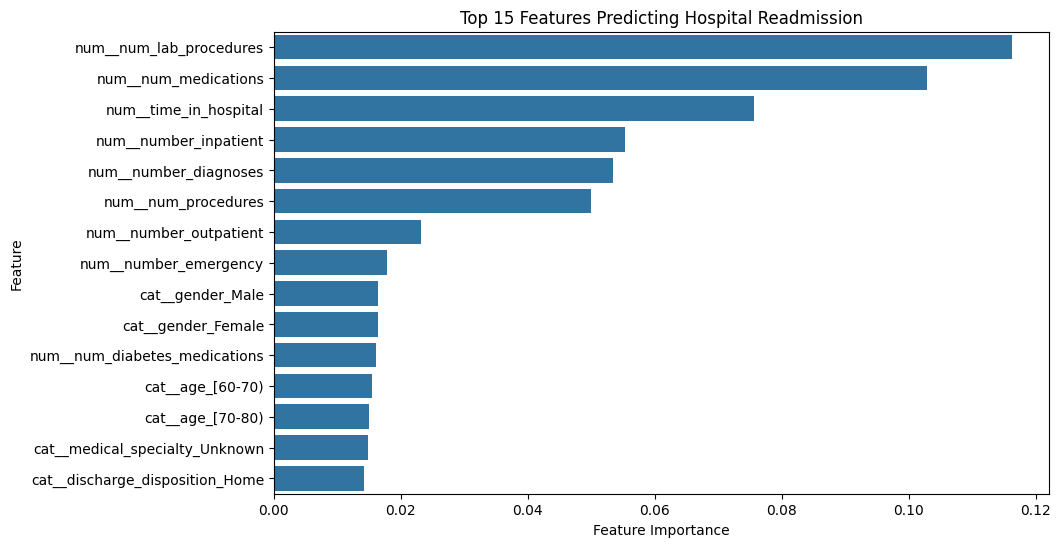

In [21]:
# Visualise the top 15 predictors from the Random Forest model
# This highlights the most influential variables for readmission prediction

top_features = feature_importance_df.head(15)


plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Features Predicting Hospital Readmission")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.show()

## Patient Readmission Risk Prediction

The final model will be used to generate patient-level readmission risk predictions.

For each patient encounter, the model will provide:

- Probability of readmission
- Predicted risk category

These outputs can help healthcare teams identify patients who may require additional monitoring, intervention, or discharge planning support.

In [22]:
# Generate readmission probability predictions using the selected model
# These probabilities represent the estimated risk of hospital readmission

# Predict probabilities on the full dataset

readmission_probability = gradient_boosting_model.predict_proba(X)[:,1]


# Create prediction dataframe

risk_predictions = pd.DataFrame({
    "patient_id": df["patient_nbr"],
    "readmission_probability": readmission_probability,
    "actual_readmission": y
})


risk_predictions.head()

,patient_id,readmission_probability,actual_readmission
0,8222157,0.275500,0
1,55629189,0.463796,1
2,86047875,0.549888,0
3,82442376,0.425418,0
4,42519267,0.305646,0


In [23]:
# Categorise patients into risk groups based on predicted probability
# Higher probability indicates greater readmission risk

def assign_risk(probability):
    if probability >= 0.60:
        return "High Risk"
    elif probability >= 0.40:
        return "Medium Risk"
    else:
        return "Low Risk"


risk_predictions["risk_category"] = (
    risk_predictions["readmission_probability"]
    .apply(assign_risk)
)


risk_predictions.head()

,patient_id,readmission_probability,actual_readmission,risk_category
0,8222157,0.275500,0,Low Risk
1,55629189,0.463796,1,Medium Risk
2,86047875,0.549888,0,Medium Risk
3,82442376,0.425418,0,Medium Risk
4,42519267,0.305646,0,Low Risk


In [24]:
# Check that risk categories were created correctly
# This displays the number of patients in each risk group

risk_predictions["risk_category"].value_counts()

risk_category
Medium Risk    46878
Low Risk       36029
High Risk      18859
Name: count, dtype: int64

In [25]:
# Create risk summary table
# This table will be exported later for dashboard reporting

risk_summary = (
    risk_predictions["risk_category"]
    .value_counts()
    .reset_index()
)

risk_summary.columns = [
    "Risk Category",
    "Number of Patients"
]

risk_summary

,Risk Category,Number of Patients
0,Medium Risk,46878
1,Low Risk,36029
2,High Risk,18859


## Final Machine Learning Summary

This notebook developed and evaluated machine learning models to predict hospital readmission risk among diabetes patients.

The target variable was created by converting the original readmission outcome into a binary classification problem:

- 1 = Patient readmitted within 30 days
- 0 = Patient not readmitted within 30 days

Three classification models were trained and evaluated:

- Logistic Regression
- Random Forest
- Gradient Boosting

The dataset was split into training and testing sets, and categorical variables were encoded using OneHotEncoder before model training.

Model performance was evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC score

Gradient Boosting was selected as the final model due to its strong predictive performance and ability to identify important factors associated with readmission risk.

Feature importance analysis identified the key predictors influencing readmission risk, helping to understand the clinical and operational factors associated with patient outcomes.

The final model was used to generate patient-level risk predictions, including:

- Readmission probability
- Predicted risk category

Patients were classified into:

- High Risk
- Medium Risk
- Low Risk

These predictions can support healthcare teams by identifying patients who may benefit from additional monitoring, targeted interventions, and improved discharge planning.

## Export Model Outputs

The final model outputs will be exported as CSV files for future analysis, dashboard development, and portfolio presentation.

The exported files include:

- Patient-level readmission risk predictions
- Model performance comparison
- Feature importance analysis
- Risk category summary

In [26]:
# Export patient-level readmission risk predictions
# This file contains individual patient risk scores and categories

risk_predictions.to_csv(
    "diabetes_readmission_predictions.csv",
    index=False
)

print("diabetes_readmission_predictions.csv exported successfully")

diabetes_readmission_predictions.csv exported successfully


In [27]:
# Rename the existing model results dataframe
# This prepares the model comparison table for export

model_comparison = model_results.copy()

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.635993,0.641667,0.476069,0.546601,0.682718
1,Random Forest,0.627985,0.610886,0.531180,0.568252,0.673273
2,Gradient Boosting,0.637811,0.638342,0.494084,0.557024,0.688677


In [28]:
# Export model performance comparison
# This file will be used for portfolio reporting and dashboard analysis

model_comparison.to_csv(
    "model_comparison.csv",
    index=False
)

print("model_comparison.csv exported successfully")

model_comparison.csv exported successfully


In [29]:
# Check the number of features used by the model
# and the number of importance values generated

print("Number of feature names:", len(X.columns))
print("Number of importance values:", len(feature_importance))

Number of feature names: 40
Number of importance values: 203


In [30]:
# Check available encoded feature names

feature_names = preprocessor.get_feature_names_out()

print("Number of encoded features:", len(feature_names))
print(feature_names[:10])

Number of encoded features: 203
['cat__race_AfricanAmerican' 'cat__race_Asian' 'cat__race_Caucasian'
 'cat__race_Hispanic' 'cat__race_Other' 'cat__race_Unknown'
 'cat__gender_Female' 'cat__gender_Male' 'cat__gender_Unknown/Invalid'
 'cat__age_[0-10)']


In [31]:
# Create feature importance dataframe using encoded feature names
# This matches the model input features correctly

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importance
})

feature_importance_df = (
    feature_importance_df
    .sort_values(
        by="Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

feature_importance_df.head(10)

,Feature,Importance
0,num__num_lab_procedures,0.116262
1,num__num_medications,0.102920
2,num__time_in_hospital,0.075576
3,num__number_inpatient,0.055345
4,num__number_diagnoses,0.053470
5,num__num_procedures,0.049951
6,num__number_outpatient,0.023121
7,num__number_emergency,0.017826
8,cat__gender_Male,0.016403
9,cat__gender_Female,0.016398


In [32]:
# Export feature importance results

feature_importance_df.to_csv(
    "feature_importance.csv",
    index=False
)

print("feature_importance.csv exported successfully")

feature_importance.csv exported successfully


In [33]:
# Export risk category summary
# This file summarises the number of patients in each predicted risk group

risk_summary.to_csv(
    "risk_summary.csv",
    index=False
)

print("risk_summary.csv exported successfully")

risk_summary.csv exported successfully


## Conclusion

This notebook successfully developed a machine learning pipeline to predict hospital readmission risk among diabetes patients.

The workflow included data preparation, feature selection, preprocessing, model training, evaluation, and interpretation of prediction results.

Three classification models were developed:

- Logistic Regression
- Random Forest
- Gradient Boosting

The models were evaluated using multiple performance metrics including accuracy, precision, recall, F1-score, and ROC-AUC. Gradient Boosting was selected as the final prediction model based on its strong predictive performance and ability to generate patient-level risk probabilities.

Feature importance analysis identified the key factors influencing readmission risk, providing insights into the clinical and operational characteristics associated with patient outcomes.

The final model was used to generate individual patient risk predictions, including:

- Readmission probability
- Predicted risk category

Patients were grouped into Low, Medium, and High-risk categories to support potential healthcare interventions, enhanced monitoring, and improved discharge planning.

The exported model outputs will be used in the next stage to create a Power BI dashboard that communicates patient risk insights, model performance, and actionable healthcare recommendations.

The completed outputs from this notebook are:

- diabetes_readmission_predictions.csv
- model_comparison.csv
- feature_importance.csv
- risk_summary.csv

These files provide the foundation for building an interactive healthcare analytics dashboard.